<a href="https://colab.research.google.com/github/abhiniveshg0-max/DEEP-LEARNING/blob/main/Experiment%203%20part%20a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 520s 3us/step
Training set shape : (50000, 32, 32, 3)
Test set shape      : (10000, 32, 32, 3)

Final dataset sizes:
Training samples   : 40000
Validation samples : 10000
Testing samples    : 10000


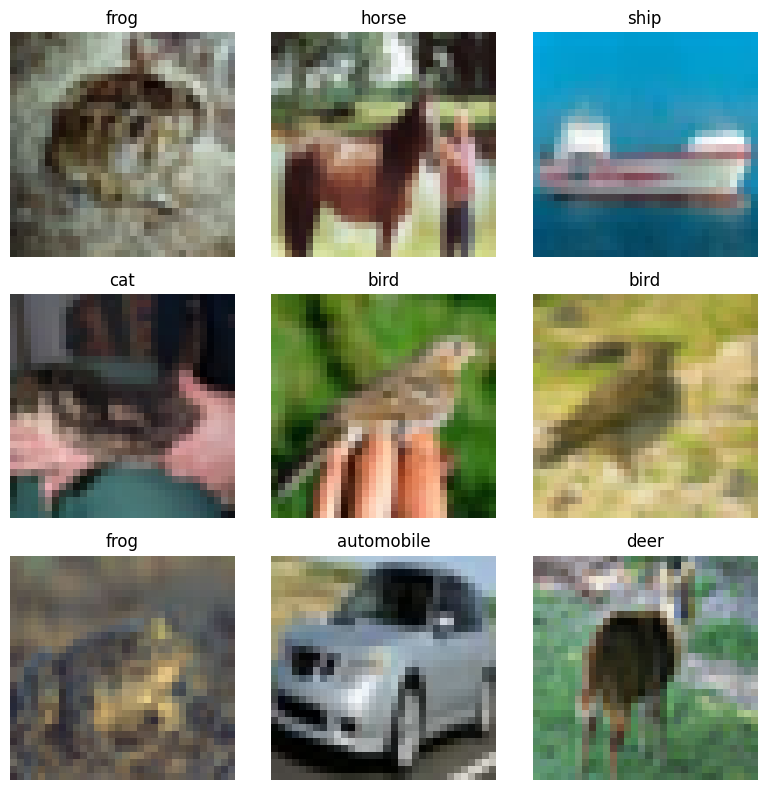

In [1]:
# =============================================================
# PART A: DATASET PREPARATION
# CNN for Image Classification — CIFAR-10
# =============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Download / Load the dataset
# -------------------------------------------------------------
# CIFAR-10 comes built into Keras, so this both "downloads" and
# "loads" it in one step (60,000 32x32 color images, 10 classes).
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set shape :", x_train_full.shape)
print("Test set shape      :", x_test.shape)

# -------------------------------------------------------------
# 2. Preprocess images: resizing and normalization
# -------------------------------------------------------------
IMG_SIZE = 32  # CIFAR-10 images are already 32x32; change if resizing is required

def preprocess(images, size=IMG_SIZE):
    # Resize (kept the same size here, but resize op is included
    # in case a different input size is needed for the model)
    images = tf.image.resize(images, (size, size)).numpy()
    # Normalize pixel values from [0, 255] to [0, 1]
    images = images.astype('float32') / 255.0
    return images

x_train_full = preprocess(x_train_full)
x_test = preprocess(x_test)

# Flatten label arrays from shape (N, 1) to (N,)
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# -------------------------------------------------------------
# 3. Split into training, validation, and testing sets
# -------------------------------------------------------------
# CIFAR-10 already provides a separate test set (x_test, y_test).
# Here we split the training set further into train + validation.
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,          # 20% held out for validation
    random_state=42,
    stratify=y_train_full   # keeps class balance across the split
)

print("\nFinal dataset sizes:")
print("Training samples   :", x_train.shape[0])
print("Validation samples :", x_val.shape[0])
print("Testing samples    :", x_test.shape[0])

# -------------------------------------------------------------
# Quick sanity check: visualize a few sample images
# -------------------------------------------------------------
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

# x_train, y_train  -> use for model.fit()
# x_val,   y_val    -> use as validation_data in model.fit()
# x_test,  y_test   -> use for final model.evaluate()